In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import shutil

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

#### Functions

In [2]:
# get pmt hx
def make_auto_pmt_hx_df(ser_row):
    # replace nan with None
    ser_row = ser_row.str.replace('nan', 'None')
    # convert to lists
    ser_row = ser_row.apply(eval)
    # make into dictionary
    dict_ser_row = dict(ser_row)
    # make df
    try:
        df_tmp = pd.DataFrame(dict_ser_row)
    except ValueError:
        dict_output = {
            # overall
            'flt_mean_months_to_first_bad': np.nan,
            # open
            'flt_payment_open': np.nan,
            'int_n_months_open': np.nan,
            'list_pmt_hx_open': np.nan,
            'flt_wtd_avg_open': np.nan,
            'flt_avg_open': np.nan,
            'int_30dpd_open': np.nan,
            'int_60dpd_open': np.nan,
            'int_90dpd_open': np.nan,
            'int_bad_3mo_open': np.nan,
            'int_bad_6mo_open': np.nan,
            'int_bad_3mo_open_end': np.nan,
            'int_bad_6mo_open_end': np.nan,
            # closed
            'flt_payment_closed': np.nan,
            'int_n_months_closed': np.nan,
            'list_pmt_hx_closed': np.nan,
            'flt_wtd_avg_closed': np.nan,
            'flt_avg_closed': np.nan,
            'int_30dpd_closed': np.nan,
            'int_60dpd_closed': np.nan,
            'int_90dpd_closed': np.nan,
            'int_bad_3mo_closed': np.nan,
            'int_bad_6mo_closed': np.nan,
            'int_bad_3mo_closed_end': np.nan,
            'int_bad_6mo_closed_end': np.nan,
        }
        # return
        return dict_output
        
    # get only auto
    df_tmp = df_tmp[df_tmp['auto__tu_pmthx'] == 1].copy()
    
    # columns
    list_cols = [
        'str_dtm_opened__tu_pmthx',
        'str_dtm_closed__tu_pmthx',
        'str_dtm_most_recent_pmt__tu_pmthx',
    ]
    # make dtm
    for col in list_cols:
        # make str_dtm_opened__tu_pmthx a datetime
        df_tmp[col] = pd.to_datetime(df_tmp[col])
    # sort
    df_tmp.sort_values(by='str_dtm_opened__tu_pmthx', ascending=False, inplace=True)
    
    # tag open
    df_tmp['tag_open'] = df_tmp['str_dtm_closed__tu_pmthx'].apply(
        lambda x: 1 if pd.isnull(x) else 0,
    )
    
    # fillna
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].fillna('')
    
    # remove Y from payment hx
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: [str_val for str_val in list(x) if str_val != 'Y'],
    )
    
    # get n payments
    df_tmp['n_months'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: len(x),
    )
    
    # convert str_pmt_hx__tu_pmthx to lists of 1 and 0
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: [1 if str_val in ['1','E'] else 0 for str_val in list(x)],
    )
    
    # reverse the order of the lists
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: x[::-1] if isinstance(x, list) else x,
    )
    
    # first month of bad event
    df_tmp['month_first_bad'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
         lambda x: pd.Series(list(x))[pd.Series(list(x)) != 1].index.min()+1,
    )
    # months to first bad
    df_tmp['months_to_first_bad'] = df_tmp['month_first_bad'].fillna(df_tmp['n_months'])
    # make it a proportion
    df_tmp['months_to_first_bad'] = df_tmp['months_to_first_bad'] / df_tmp['n_months']
    
    # get mean proportion months to first bad overall open and closed - all
    flt_mean_months_to_first_bad = df_tmp['months_to_first_bad'].mean()
    
    # get mean proportion months to first bad overall open and closed - all
    flt_mean_months_to_first_bad = df_tmp['months_to_first_bad'].mean()
    # logic if there is no payment history
    if pd.isnull(flt_mean_months_to_first_bad):
        flt_mean_months_to_first_bad = 0 # lower is worse it means you have early delinquency
    else:
        pass
    
    # get df open
    df_tmp_open = df_tmp[df_tmp['tag_open'] == 1].copy()
    int_nrows = df_tmp_open.shape[0]
    if int_nrows > 0:
        # get mayment
        flt_payment_open = df_tmp_open['flt_payment__tu_pmthx'].iloc[0]
        # get n months
        int_n_months_open = df_tmp_open['n_months'].iloc[0]
        # get the most recent open pmt hx
        list_pmt_hx_open = df_tmp_open['str_pmt_hx__tu_pmthx'].iloc[0]
        # get weighted average
        list_weights = list(range(1, len(list_pmt_hx_open)+1))
        try:
            flt_wtd_avg_open = np.average(list_pmt_hx_open, weights=list_weights)
        except ZeroDivisionError:
            flt_wtd_avg_open = np.nan # lower is worse
        # get normal average
        flt_avg_open = np.mean(list_pmt_hx_open)
        # get DPD
        int_30dpd_open = df_tmp_open['flt_30_dpd__tu_pmthx'].iloc[0]
        int_60dpd_open = df_tmp_open['flt_60_dpd__tu_pmthx'].iloc[0]
        int_90dpd_open = df_tmp_open['flt_90_dpd__tu_pmthx'].iloc[0]
        
        # bad tags
        int_len_list_pmt_hx_open = len(list_pmt_hx_open)
        
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_3mo_open = 1
        elif (int_len_list_pmt_hx_open >= 3) and (np.sum(list_pmt_hx_open[:3]) < 3):
            int_bad_3mo_open = 1
        else:
            int_bad_3mo_open = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_6mo_open = 1
        elif (int_len_list_pmt_hx_open >= 6) and (np.sum(list_pmt_hx_open[:6]) < 6):
            int_bad_6mo_open = 1
        else:
            int_bad_6mo_open = 0
        
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_3mo_open_end = 1
        elif (int_len_list_pmt_hx_open >= 3) and (np.sum(list_pmt_hx_open[-3:]) < 3):
            int_bad_3mo_open_end = 1
        else:
            int_bad_3mo_open_end = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_open < 3:
            int_bad_6mo_open_end = 1
        elif (int_len_list_pmt_hx_open >= 6) and (np.sum(list_pmt_hx_open[-6:]) < 6):
            int_bad_6mo_open_end = 1
        else:
            int_bad_6mo_open_end = 0
    else:
        flt_payment_open = np.nan
        int_n_months_open = np.nan
        list_pmt_hx_open = np.nan
        flt_wtd_avg_open = np.nan
        flt_avg_open = np.nan
        int_30dpd_open = np.nan
        int_60dpd_open = np.nan
        int_90dpd_open = np.nan
        int_bad_3mo_open = np.nan
        int_bad_6mo_open = np.nan
        int_bad_3mo_open_end = np.nan
        int_bad_6mo_open_end = np.nan
    
    # get df closed
    df_tmp_closed = df_tmp[df_tmp['tag_open'] == 0].copy()
    int_nrows = df_tmp_closed.shape[0]
    if int_nrows > 0:
        # get mayment
        flt_payment_closed = df_tmp_closed['flt_payment__tu_pmthx'].iloc[0]
        # get n months
        int_n_months_closed = df_tmp_closed['n_months'].iloc[0]
        # get the most recent open pmt hx
        list_pmt_hx_closed = df_tmp_closed['str_pmt_hx__tu_pmthx'].iloc[0]
        # get weighted average
        list_weights = list(range(1, len(list_pmt_hx_closed)+1))
        try:
            flt_wtd_avg_closed = np.average(list_pmt_hx_closed, weights=list_weights)
        except ZeroDivisionError:
            flt_wtd_avg_closed = np.nan
        # get normal average
        flt_avg_closed = np.mean(list_pmt_hx_closed)
        # get DPD
        int_30dpd_closed = df_tmp_closed['flt_30_dpd__tu_pmthx'].iloc[0]
        int_60dpd_closed = df_tmp_closed['flt_60_dpd__tu_pmthx'].iloc[0]
        int_90dpd_closed = df_tmp_closed['flt_90_dpd__tu_pmthx'].iloc[0]
        
        # bad tags
        int_len_list_pmt_hx_closed = len(list_pmt_hx_closed)
        
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_3mo_closed = 1
        elif (int_len_list_pmt_hx_closed >= 3) and (np.sum(list_pmt_hx_closed[:3]) < 3):
            int_bad_3mo_closed = 1
        else:
            int_bad_3mo_closed = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_6mo_closed = 1
        elif (int_len_list_pmt_hx_closed >= 6) and (np.sum(list_pmt_hx_closed[:6]) < 6):
            int_bad_6mo_closed = 1
        else:
            int_bad_6mo_closed = 0
            
        # if they dont have 3 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_3mo_closed_end = 1
        elif (int_len_list_pmt_hx_closed >= 3) and (np.sum(list_pmt_hx_closed[-3:]) < 3):
            int_bad_3mo_closed_end = 1
        else:
            int_bad_3mo_closed_end = 0
        
        # if they dont have 6 months on file
        if int_len_list_pmt_hx_closed < 3:
            int_bad_6mo_closed_end = 1
        elif (int_len_list_pmt_hx_closed >= 6) and (np.sum(list_pmt_hx_closed[-6:]) < 6):
            int_bad_6mo_closed_end = 1
        else:
            int_bad_6mo_closed_end = 0
    else:
        flt_payment_closed = np.nan
        int_n_months_closed = np.nan
        list_pmt_hx_closed = np.nan
        flt_wtd_avg_closed = np.nan
        flt_avg_closed = np.nan
        int_30dpd_closed = np.nan
        int_60dpd_closed = np.nan
        int_90dpd_closed = np.nan
        int_bad_3mo_closed = np.nan
        int_bad_6mo_closed = np.nan
        int_bad_3mo_closed_end = np.nan
        int_bad_6mo_closed_end = np.nan
    
    # dict output
    dict_output = {
        # overall
        'flt_mean_months_to_first_bad': flt_mean_months_to_first_bad,
        # open
        'flt_payment_open': flt_payment_open,
        'int_n_months_open': int_n_months_open,
        'list_pmt_hx_open': list_pmt_hx_open,
        'flt_wtd_avg_open': flt_wtd_avg_open,
        'flt_avg_open': flt_avg_open,
        'int_30dpd_open': int_30dpd_open,
        'int_60dpd_open': int_60dpd_open,
        'int_90dpd_open': int_90dpd_open,
        'int_bad_3mo_open': int_bad_3mo_open,
        'int_bad_6mo_open': int_bad_6mo_open,
        'int_bad_3mo_open_end': int_bad_3mo_closed_end,
        'int_bad_6mo_open_end': int_bad_6mo_closed_end,
        # closed
        'flt_payment_closed': flt_payment_closed,
        'int_n_months_closed': int_n_months_closed,
        'list_pmt_hx_closed': list_pmt_hx_closed,
        'flt_wtd_avg_closed': flt_wtd_avg_closed,
        'flt_avg_closed': flt_avg_closed,
        'int_30dpd_closed': int_30dpd_closed,
        'int_60dpd_closed': int_60dpd_closed,
        'int_90dpd_closed': int_90dpd_closed,
        'int_bad_3mo_closed': int_bad_3mo_closed,
        'int_bad_6mo_closed': int_bad_6mo_closed,
        'int_bad_3mo_closed_end': int_bad_3mo_closed_end,
        'int_bad_6mo_closed_end': int_bad_6mo_closed_end,
    }
    
    # return
    return dict_output

In [3]:
def map_ltv_range_to_lgd_bin(flt_ltv, dict_bins_ltv):
    for flt_threshold, flt_val in dict_bins_ltv.items():
        if flt_ltv <= flt_threshold:
            return flt_val
    # else
    return np.max(list(dict_bins_ltv.values()))

In [4]:
def get_lgd_bk_nobk(int_bk, flt_lgd_bk, flt_lgd_nobk):
    # if bk
    if int_bk == 1:
        return flt_lgd_bk
    else:
        return flt_lgd_nobk

#### Constants

In [5]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

list_str_inst = [
    # from ben: 2025-02-21
    'CURRENT',
    'SELF',
    # key words
    'CHIME-STRIDE',
    'CHIMEFINAL',
    # from dustin: 2025-02-24
    'SELF FIN',
    'SELF/LEAD',
    'SELFINC/LEAD',
    'SBNASELFLNDR',
    'SBNA SELF',
    'CHIME',
    'CLEO',
    'CLEO AI',
    'VARO',
    'ATLAS',
    'ATLCAPBKSELF',
    'POSSIBLE',
    'POSSIBLE FIN',
    'KIKOFF',
    'SUPER.COM',
    'STEP',
    'STEP MOBILE',
    'BRIGHT',
    'BRIGHT BLDR',
    'FIG TECH INC',
    'SELF/RENT',
    'SELFBILLSE',
    'PROGRESSRES',
    'FLEX',
    'FLEXFINANCE',
]

flt_factor_chime = 1.203
flt_factor_nonchime = 0.936

Project: 20241112-simple-model-test
Task: 09_60_in_720
Subtask: 03_get_predictions


#### Output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [7]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,linkf206__tu,linkf207__tu,linkf208__tu,linkf209__tu,linkf210__tu,linkf211__tu,linkf212__tu,linkf213__tu,totalincome__app,totaldebt__app
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,0.0,235.0,0.0,4.0,0.0,1005.0,0.0,0.48,NaN,NaN
0,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0.0,0.0,0.0,0.0,7.0,0.0,1166.0,0.95,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5560.0,2742.65
0,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
0,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Engineer pmt hx

In [8]:
%%time

# pmt history columns
list_cols_pmt_hx = [col for col in df.columns if '__tu_pmthx' in col]
# get pmt hx
df['pmt_hx'] = df[list_cols_pmt_hx].apply(
    lambda x: make_auto_pmt_hx_df(ser_row=x),
    axis=1,
)

# get the pmt hx
df_tmp = pd.DataFrame(list(df['pmt_hx']))
list_cols = [f'{col}__tu_pmthx' for col in df_tmp.columns]
df_tmp.columns = list_cols
# reset index
df = df.reset_index(drop=True)
df_tmp = df_tmp.reset_index(drop=True)
# concat
df = pd.concat([df, df_tmp], axis=1)

# show
df

CPU times: user 1min 38s, sys: 114 ms, total: 1min 38s
Wall time: 1min 38s


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,list_pmt_hx_closed__tu_pmthx,flt_wtd_avg_closed__tu_pmthx,flt_avg_closed__tu_pmthx,int_30dpd_closed__tu_pmthx,int_60dpd_closed__tu_pmthx,int_90dpd_closed__tu_pmthx,int_bad_3mo_closed__tu_pmthx,int_bad_6mo_closed__tu_pmthx,int_bad_3mo_closed_end__tu_pmthx,int_bad_6mo_closed_end__tu_pmthx
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.355556,0.592593,0.0,1.0,1.0,0.0,0.0,1.0,1.0
1,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,"[1, 1, 1, 1, 1, 1]",1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.002551,0.041667,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11857,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.370873,0.606061,1.0,0.0,0.0,0.0,0.0,1.0,1.0
11858,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.874384,0.928571,1.0,1.0,0.0,0.0,0.0,1.0,1.0
11859,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, ...",0.087347,0.285714,2.0,1.0,1.0,0.0,0.0,1.0,1.0


#### Create chime tag

In [9]:
df['list_institutions'] = df['str_institution__tu_pmthx'].apply(
    lambda x: eval(x.replace('nan','None')),
)
df['list_institutions'] = df['list_institutions'].apply(
    lambda x: [] if x is None else x,
)
# show
#df

In [10]:
list_str_col_new = []
for str_inst in tqdm(list_str_inst):
    str_col_new = f'{str_inst}_tag'
    df[str_col_new] = df['list_institutions'].apply(
        lambda x: 1 if str_inst in x else 0,
    )
    list_str_col_new.append(str_col_new)

100%|██████████| 29/29 [00:00<00:00, 156.70it/s]


In [11]:
df['sum'] = df[list_str_col_new].sum(axis=1)
df['has_inst_tag'] = df['sum'].apply(
    lambda x: 1 if x > 0 else 0,
)
flt_mn = df['has_inst_tag'].mean()
print(f'Proportion has tag: {flt_mn:0.4f}')
# show
#df

Proportion has tag: 0.3881


#### Prep data

In [12]:
# get script
str_filename = 'preprocessing.py'
str_origin = f'../../08_prep_data/{str_filename}'
str_destination = f'./{str_filename}'
shutil.copyfile(str_origin, str_destination)

# read preprocessor
str_filename = 'cls_model_preprocessing.pkl'
str_local_path = f'../../08_prep_data/output/{str_filename}'
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

# preprocess
df = cls_model_preprocessing.transform(df)

# rm
os.remove('./preprocessing.py')

# show
df

Masking negative values to NaN...


100%|██████████| 2113/2113 [00:01<00:00, 1375.62it/s]


Capping income...
Replacing zeros...


100%|██████████| 3/3 [00:00<00:00, 1610.10it/s]


Engineering number of months...
Engineering number of months total...
Engineering weighted average...
Engineering tag for has auto...
Engineering tag for open auto indicator...
Engineering tag for closed auto indicator...
Engineering tag for open and closed auto indicator...
Engineering 3 month early delinquency...
Engineering 6 month early delinquency...
Engineering 3 month recent delinquency...
Engineering 6 month recent delinquency...
Engineering DTI...
Engineering franchise...
Engineering has a codebtor...
Engineering vehicle age...
Engineering PTI...
Engineering LTV...
Engineering BK...
Engineering perfect payment history tag for most recent auto...
Engineering perfect payment history tag for open auto...
Engineering perfect payment history tag for closed auto...
Engineering interactions...
Imputing values...


0it [00:00, ?it/s]


Binning values for scorecard...


0it [00:00, ?it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,1,0,-1,0.086140,0.915865,0,0,0,0,0.0
1,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0,0,6,NaN,1.114885,0,0,0,0,NaN
2,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,1,0,2,0.050223,1.064409,0,1,1,1,0.0
3,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,0,0,5,0.152250,0.858740,0,0,0,0,0.0
4,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0,0,5,NaN,1.057082,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,0,1,5,0.239000,1.247431,0,1,1,0,0.0
11857,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,0,1,5,0.276172,1.247431,0,1,1,0,0.0
11858,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,1,0,4,NaN,1.086957,0,0,0,0,0.0
11859,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,1,0,-1,0.142857,1.217608,0,1,1,0,0.0


#### Get imputation dictionary

In [13]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

#### Impute

In [14]:
for key, val in tqdm(dict_impute.items()):
    df[key] = df[key].fillna(val)

100%|██████████| 1123/1123 [00:00<00:00, 3044.53it/s]


#### Predictions from scorecard

In [15]:
# load model
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)

# load binner
str_filename = 'dict_bins.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# bin
df_tmp = df.copy()
for key, val in tqdm(dict_bins.items()):
    df_tmp[f'{key}_binned'] = val.transform(df_tmp[key])

# predict
df['PD'] = cls_model_inference.predict_proba(df_tmp[list_cols_model])[:,1]
# save memory
del df_tmp
# show
df

100%|██████████| 1119/1119 [00:01<00:00, 892.93it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,PD
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,0,-1,0.086140,0.915865,0,0,0,0,0.0,0.318387
1,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,0,6,402.000000,1.114885,0,0,0,0,0.0,0.663880
2,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,0,2,0.050223,1.064409,0,1,1,1,0.0,0.270747
3,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,0,5,0.152250,0.858740,0,0,0,0,0.0,0.577737
4,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,0,5,402.000000,1.057082,0,0,0,0,0.0,0.457385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,1,5,0.239000,1.247431,0,1,1,0,0.0,0.595561
11857,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,1,5,0.276172,1.247431,0,1,1,0,0.0,0.535946
11858,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,0,4,402.000000,1.086957,0,0,0,0,0.0,0.439233
11859,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,0,-1,0.142857,1.217608,0,1,1,0,0.0,0.340146


#### LGD (BK)

In [16]:
# open
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../../create_grid/01_60_in_720_bk_chargeoff/output/{str_filename}'
dict_bins_ltv_bk = pickle.load(open(str_local_path, 'rb'))

# get lgd
df['LGD_bk'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv_bk,
    ),
)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,PD,LGD_bk
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,-1,0.086140,0.915865,0,0,0,0,0.0,0.318387,0.161799
1,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,6,402.000000,1.114885,0,0,0,0,0.0,0.663880,0.259641
2,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,2,0.050223,1.064409,0,1,1,1,0.0,0.270747,0.259641
3,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,5,0.152250,0.858740,0,0,0,0,0.0,0.577737,0.161799
4,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,5,402.000000,1.057082,0,0,0,0,0.0,0.457385,0.259641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,5,0.239000,1.247431,0,1,1,0,0.0,0.595561,0.293804
11857,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,5,0.276172,1.247431,0,1,1,0,0.0,0.535946,0.293804
11858,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,4,402.000000,1.086957,0,0,0,0,0.0,0.439233,0.259641
11859,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,-1,0.142857,1.217608,0,1,1,0,0.0,0.340146,0.293804


In [17]:
dict_bins_ltv_bk

{0.76: 0.01,
 0.81: 0.01,
 0.94: 0.1617987878136479,
 1.03: 0.17289834384226316,
 1.16: 0.2596410016840132,
 1.2: 0.2899966430839025,
 1.25: 0.2938038635922092,
 1.29: 0.31672530923551634,
 1.34: 0.3232454576829602,
 1.43: 0.33346304982454933,
 1.47: 0.3555088501813138,
 1.56: 0.39086345320128246,
 1.604350110619469: 0.4162304395202057}

#### LGD (no BK)

In [18]:
# open
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../../create_grid/02_60_in_720_nobk_chargeoff/output/{str_filename}'
dict_bins_ltv_nobk = pickle.load(open(str_local_path, 'rb'))

# get lgd
df['LGD_nobk'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv_nobk,
    ),
)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,PD,LGD_bk,LGD_nobk
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,8439574/i1aJ-2024-12-03-01:40:04,1,8439574104198171,8439574,10419817,1,Illinois,...,0.086140,0.915865,0,0,0,0,0.0,0.318387,0.161799,0.277756
1,8564134,2025-01-14 07:37:54+00:00,GEN-XII,8564134/WCm0-2025-01-14-00:37:54,1,8564134105623331,8564134,10562333,1,Utah,...,402.000000,1.114885,0,0,0,0,0.0,0.663880,0.259641,0.337281
2,8489707,2024-12-15 06:08:17+00:00,GEN-XII,8489707/Hszr-2024-12-14-23:08:17,1,8489707104756971,8489707,10475697,1,California,...,0.050223,1.064409,0,1,1,1,0.0,0.270747,0.259641,0.337281
3,8554640,2025-01-10 05:31:51+00:00,GEN-XII,8554640/tyE2-2025-01-09-22:31:51,1,8554640105510811,8554640,10551081,1,Indiana,...,0.152250,0.858740,0,0,0,0,0.0,0.577737,0.161799,0.277756
4,8425624,2024-11-26 22:41:51+00:00,GEN-XII,8425624/jJ6Y-2024-11-26-15:41:51,1,8425624104031221,8425624,10403122,1,Wisconsin,...,402.000000,1.057082,0,0,0,0,0.0,0.457385,0.259641,0.337281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,1,8574699105747531,8574699,10574753,1,Oklahoma,...,0.239000,1.247431,0,1,1,0,0.0,0.595561,0.293804,0.350185
11857,8574699,2025-01-18 02:42:42+00:00,GEN-XII,8574699/63fa-2025-01-17-19:42:42,0,8574699105747540,8574699,10574754,0,Oklahoma,...,0.276172,1.247431,0,1,1,0,0.0,0.535946,0.293804,0.350185
11858,8528513,2024-12-29 04:14:24+00:00,GEN-XII,8528513/9KQ3-2024-12-28-21:14:24,1,8528513105200701,8528513,10520070,1,Maryland,...,402.000000,1.086957,0,0,0,0,0.0,0.439233,0.259641,0.337281
11859,8506878,2024-12-19 02:10:09+00:00,GEN-XII,8506878/Plr6-2024-12-18-19:10:09,1,8506878104941931,8506878,10494193,1,Ohio,...,0.142857,1.217608,0,1,1,0,0.0,0.340146,0.293804,0.350185


In [19]:
dict_bins_ltv_nobk

{0.5: 0.01,
 0.82: 0.19939686644815996,
 1.03: 0.27775640912627786,
 1.14: 0.3372811670434425,
 1.25: 0.3501845945669622,
 1.46: 0.39004257415648635,
 1.57: 0.3904153872148606,
 1.67: 0.41688126579694246,
 2.21: 0.5660710264644647,
 2.526389: 0.6052945473058466}

#### LGD

In [20]:
# get lgd
df['LGD'] = df.apply(
    lambda x: get_lgd_bk_nobk(
        int_bk=x['ENG-bk'],
        flt_lgd_bk=x['LGD_bk'],
        flt_lgd_nobk=x['LGD_nobk'],
    ),
    axis=1,
)

#### Subset

In [21]:
list_cols = [
    'accountid',
    'request_datetime',
    'response_model_name',
    'bitdebtor',
    'ENG-bk',
    'PD',
    'LGD',
    'has_inst_tag',
]
df = df[list_cols].copy()
# show
df

,accountid,request_datetime,response_model_name,bitdebtor,ENG-bk,PD,LGD,has_inst_tag
0,8439574,2024-12-03 08:40:04+00:00,GEN-XII,1,0,0.318387,0.277756,1
1,8564134,2025-01-14 07:37:54+00:00,GEN-XII,1,0,0.663880,0.337281,1
2,8489707,2024-12-15 06:08:17+00:00,GEN-XII,1,0,0.270747,0.337281,0
3,8554640,2025-01-10 05:31:51+00:00,GEN-XII,1,0,0.577737,0.277756,1
4,8425624,2024-11-26 22:41:51+00:00,GEN-XII,1,0,0.457385,0.337281,1
...,...,...,...,...,...,...,...,...
11856,8574699,2025-01-18 02:42:42+00:00,GEN-XII,1,0,0.595561,0.350185,1
11857,8574699,2025-01-18 02:42:42+00:00,GEN-XII,0,0,0.535946,0.350185,0
11858,8528513,2024-12-29 04:14:24+00:00,GEN-XII,1,0,0.439233,0.337281,1
11859,8506878,2024-12-19 02:10:09+00:00,GEN-XII,1,0,0.340146,0.350185,0


#### Save locally

In [22]:
%%time

str_filename = 'df_predictions.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

CPU times: user 44.2 ms, sys: 0 ns, total: 44.2 ms
Wall time: 43.2 ms


#### Group by account

In [23]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'last',
    'response_model_name': 'last',
    'ENG-bk': 'first',
    'PD': 'mean',
    'LGD': 'mean',
    'has_inst_tag': 'max',
})
# get ecnl
df_tmp['ECNL'] = df_tmp['PD'] * df_tmp['LGD'] * flt_factor_24_to_72
# show
df_tmp

,accountid,request_datetime,response_model_name,ENG-bk,PD,LGD,has_inst_tag,ECNL
0,5782431,2024-12-20 01:09:20+00:00,GEN-XII,0,0.541495,0.390043,0,0.498446
1,8292595,2024-11-28 06:54:03+00:00,GEN-XII,0,0.282371,0.199397,1,0.132877
2,8300223,2024-12-03 01:52:59+00:00,GEN-XII,1,0.279107,0.172898,1,0.113887
3,8303160,2024-11-29 23:18:44+00:00,GEN-XII,0,0.723017,0.350185,0,0.597527
4,8306424,2024-12-17 02:28:46+00:00,GEN-XII,0,0.481201,0.350185,1,0.397682
...,...,...,...,...,...,...,...,...
9995,8582527,2025-01-21 06:47:43+00:00,GEN-XII,0,0.469815,0.390043,0,0.432465
9996,8582538,2025-01-21 06:50:53+00:00,GEN-XII,0,0.468389,0.277756,0,0.307031
9997,8582546,2025-01-21 06:52:28+00:00,GEN-XII,0,0.714612,0.350185,1,0.590581
9998,8582550,2025-01-21 06:53:56+00:00,GEN-XII,0,0.218197,0.277756,0,0.143029


#### Chime penalty

In [24]:
df_tmp['ECNL'] = df_tmp.apply(
    lambda x: (x['ECNL'] * flt_factor_chime) if x['has_inst_tag'] == 1 else (x['ECNL'] * flt_factor_nonchime),
    axis=1,
)
# clip
df_tmp['ECNL'] = df_tmp['ECNL'].clip(lower=0)

#### Save locally

In [25]:
%%time

str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_parquet(str_local_path, compression='gzip')

CPU times: user 34.9 ms, sys: 4.06 ms, total: 38.9 ms
Wall time: 37.9 ms


#### Distribution

100%|██████████| 3/3 [00:00<00:00,  5.37it/s]


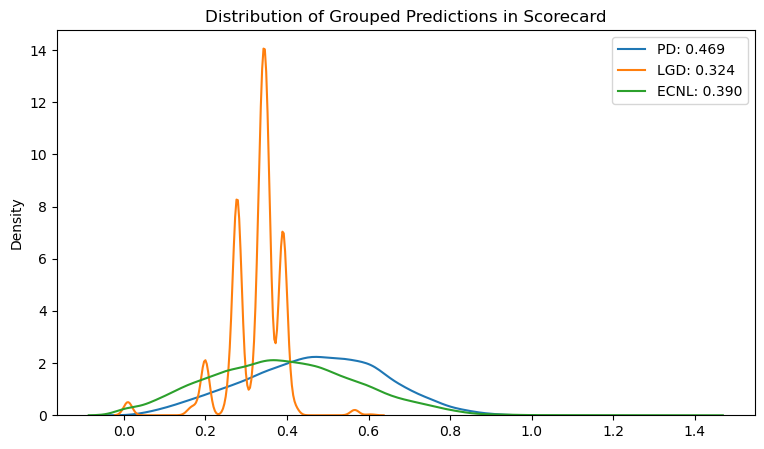

In [26]:
list_cols = [
    'PD',
    'LGD',
    'ECNL',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distribution of Grouped Predictions in Scorecard')
for col in tqdm(list_cols):
    flt_mn = df_tmp[col].mean()
    str_label = f'{col}: {flt_mn:0.3f}'
    sns.kdeplot(list(df_tmp[col]), label=str_label, ax=ax)
# legend
ax.legend()
# show
plt.show()

#### Get quantiles for each set of predictions

In [27]:
list_cols = [
    'PD',
    'LGD',
    'ECNL',
]
for col in tqdm(list_cols):
    # ml
    arr_score_quantiles = np.percentile(
        list(df_tmp[col]),
        np.linspace(0, 100, 100),
    )
    # save
    str_filename = f'arr_score_quantiles_{col}.pkl'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    pickle.dump(arr_score_quantiles, open(str_local_path, 'wb'))

100%|██████████| 3/3 [00:00<00:00, 334.53it/s]
